**Dependency note:** this notebook needs kernel state from **`01_Tutorial_and_Data_Loading`**. Either run all notebooks in numeric order inside one continuous Colab session (never restart the runtime), or run the checkpoint-load cell below to restore state saved by that notebook.

In [ ]:
# ── CHECKPOINT: restore kernel state from the previous notebook ──
# This notebook depends on variables created in 01.
# Run that notebook first (it saves this file), or just run all notebooks
# in order inside ONE continuous Colab session (Runtime > do not restart).
import dill
dill.load_session("checkpoints/01_state.pkl")
print("Restored checkpoint: checkpoints/01_state.pkl")

In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# Get all unique nodes
all_nodes = sorted(node_degree.keys())
node_idx = {n: i for i, n in enumerate(all_nodes)}
n_nodes = len(all_nodes)
n_edges = len(hyperedges)
edge_list = list(hyperedges.keys())
edge_idx = {e: i for i, e in enumerate(edge_list)}

# Build incidence matrix B (nodes x edges)
rows, cols = [], []
for edge, nodes in hyperedges.items():
    e_i = edge_idx[edge]
    for node in nodes:
        rows.append(node_idx[node])
        cols.append(e_i)

B = sp.csr_matrix(
    (np.ones(len(rows)), (rows, cols)),
    shape=(n_nodes, n_edges)
)

# Degree matrix of nodes (Dv) and edges (De)
Dv = sp.diags([node_degree[n] for n in all_nodes])
De = sp.diags([len(hyperedges[e]) for e in edge_list])

# Hypergraph Laplacian: L = Dv - B * De_inv * B^T
De_inv = sp.diags([1.0 / len(hyperedges[e]) for e in edge_list])
L = Dv - B.dot(De_inv).dot(B.T)

print(f"Laplacian matrix shape: {L.shape}")
print(f"Laplacian is symmetric: {(L - L.T).nnz == 0}")

# Compute smallest eigenvalues (spectral gap)
eigenvalues, _ = spla.eigsh(L.astype(float), k=6, which='SM')
eigenvalues = np.sort(np.real(eigenvalues))

print(f"\nSmallest eigenvalues:")
for i, ev in enumerate(eigenvalues):
    print(f"  λ{i} = {ev:.6f}")

print(f"\nSpectral gap (λ1 - λ0): {eigenvalues[1] - eigenvalues[0]:.6f}")

Laplacian matrix shape: (852, 852)
Laplacian is symmetric: True

Smallest eigenvalues:
  λ0 = 0.000000
  λ1 = 3.700991
  λ2 = 5.653084
  λ3 = 10.694056
  λ4 = 17.580166
  λ5 = 18.452459

Spectral gap (λ1 - λ0): 3.700991


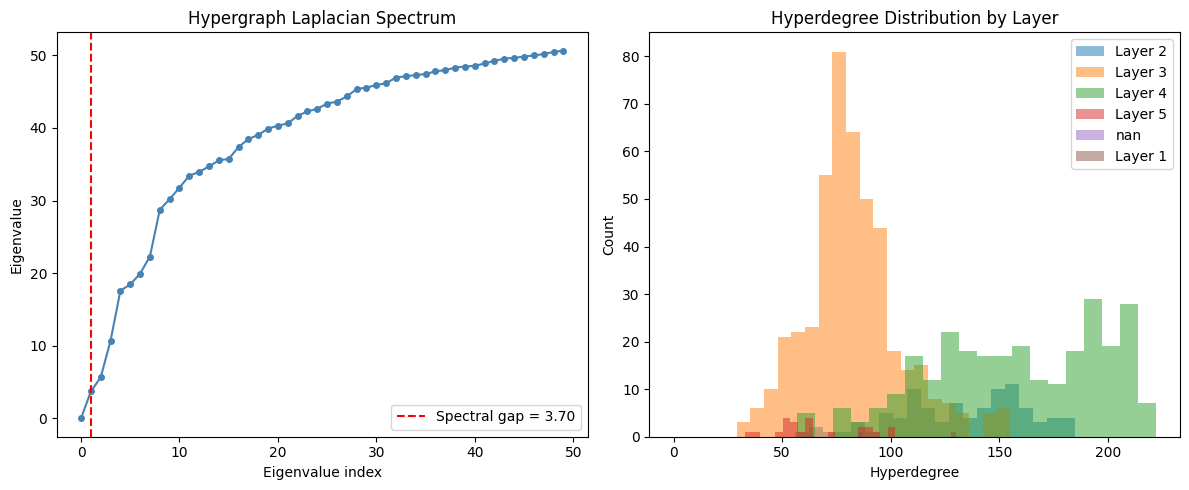

Spectral gap: 3.7010
This indicates a well connected hypergraph


In [ ]:
# Compute more eigenvalues for full spectrum plot
eigenvalues_full, _ = spla.eigsh(L.astype(float), k=50, which='SM')
eigenvalues_full = np.sort(np.real(eigenvalues_full))

plt.figure(figsize=(12, 5))

# Plot 1: Eigenvalue spectrum
plt.subplot(1, 2, 1)
plt.plot(eigenvalues_full, 'o-', color='steelblue', markersize=4)
plt.axvline(x=1, color='red', linestyle='--', label=f'Spectral gap = {eigenvalues_full[1]:.2f}')
plt.title('Hypergraph Laplacian Spectrum')
plt.xlabel('Eigenvalue index')
plt.ylabel('Eigenvalue')
plt.legend()

# Plot 2: Hyperdegree distribution by layer
plt.subplot(1, 2, 2)
for layer in inter_patch['layer'].unique():
    subset = inter_patch[inter_patch['layer'] == layer]['hyperdegree']
    plt.hist(subset, bins=20, alpha=0.5, label=layer)
plt.title('Hyperdegree Distribution by Layer')
plt.xlabel('Hyperdegree')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Spectral gap: {eigenvalues_full[1]:.4f}")
print(f"This indicates a {'well' if eigenvalues_full[1] > 1 else 'poorly'} connected hypergraph")

In [ ]:
# Save your results so far
results_summary = {
    'patch_size': len(patch),
    'n_hyperedges': len(hyperedges),
    'n_nodes': len(node_degree),
    'avg_hyperdegree': np.mean(degrees),
    'max_hyperdegree': np.max(degrees),
    'spectral_gap': float(eigenvalues_full[1]),
    'top_hub_layer': patch.loc[most_connected]['layer'],
    'top_hub_hyperdegree': node_degree[most_connected]
}

print("=== Research Results Summary ===")
for k, v in results_summary.items():
    print(f"  {k}: {v}")

# Save patch data with hyperdegree
patch.to_csv('h01_patch_results.csv', index=True)
print("\nData saved to h01_patch_results.csv")

=== Research Results Summary ===
  patch_size: 2618
  n_hyperedges: 1766
  n_nodes: 852
  avg_hyperdegree: 111.72535211267606
  max_hyperdegree: 222
  spectral_gap: 3.7009907236909942
  top_hub_layer: Layer 4
  top_hub_hyperdegree: 222

Data saved to h01_patch_results.csv


In [ ]:
# Integration hyperedges: for each interneuron, find all pyramidal neurons broadcasting to it
pyramidal = patch[patch['celltype'] == 'PYRAMIDAL']
interneurons = patch[patch['celltype'] == 'INTERNEURON']

integration_hyperedges = {}

for idx, inter_neuron in interneurons.iterrows():
    # Find pyramidal neurons within proximity threshold
    distances = np.sqrt(
        (pyramidal['x'] - inter_neuron['x'])**2 +
        (pyramidal['y'] - inter_neuron['y'])**2 +
        (pyramidal['z'] - inter_neuron['z'])**2
    )
    nearby_pyr = pyramidal[distances < proximity_threshold].index.tolist()

    if len(nearby_pyr) >= 2:  # only keep if receiving from 2+ pyramidal neurons
        integration_hyperedges[f"inter_{idx}"] = nearby_pyr

print(f"Total integration hyperedges: {len(integration_hyperedges)}")
print(f"Sample sizes: {[len(v) for v in list(integration_hyperedges.values())[:10]]}")

# Compare with broadcast
print(f"\nBroadcast hyperedges (Pyr → Inter): {len(hyperedges)}")
print(f"Integration hyperedges (Pyr → Inter): {len(integration_hyperedges)}")

Total integration hyperedges: 852
Sample sizes: [160, 138, 62, 76, 151, 81, 93, 139, 87, 60]

Broadcast hyperedges (Pyr → Inter): 1766
Integration hyperedges (Pyr → Inter): 852


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Integration Laplacian shape: (1766, 1766)
Integration spectral gap: 1.7959
Broadcast spectral gap:   3.7010


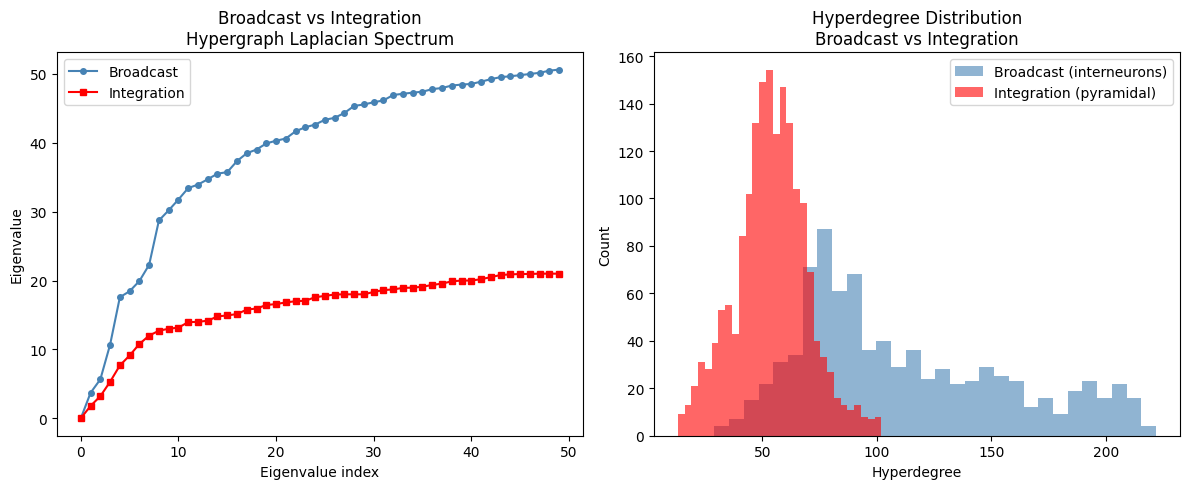


Broadcast avg hyperdegree: 111.73
Integration avg hyperdegree: 53.90


In [ ]:
# Build integration hypergraph structures
int_node_degree = {}
for edge, nodes in integration_hyperedges.items():
    for node in nodes:
        int_node_degree[node] = int_node_degree.get(node, 0) + 1

# All nodes are pyramidal neurons this time
int_all_nodes = sorted(int_node_degree.keys())
int_node_idx = {n: i for i, n in enumerate(int_all_nodes)}
int_n_nodes = len(int_all_nodes)
int_edge_list = list(integration_hyperedges.keys())
int_edge_idx = {e: i for i, e in enumerate(int_edge_list)}

# Build incidence matrix
rows, cols = [], []
for edge, nodes in integration_hyperedges.items():
    e_i = int_edge_idx[edge]
    for node in nodes:
        rows.append(int_node_idx[node])
        cols.append(e_i)

B_int = sp.csr_matrix(
    (np.ones(len(rows)), (rows, cols)),
    shape=(int_n_nodes, len(int_edge_list))
)

# Build integration Laplacian
Dv_int = sp.diags([float(int_node_degree[n]) for n in int_all_nodes])
De_int_inv = sp.diags([1.0 / len(integration_hyperedges[e]) for e in int_edge_list])
L_int = Dv_int - B_int.dot(De_int_inv).dot(B_int.T)

# Compute eigenvalues
evals_int, _ = spla.eigsh(L_int.astype(float), k=50, which='SM')
evals_int = np.sort(np.real(evals_int))

print(f"Integration Laplacian shape: {L_int.shape}")
print(f"Integration spectral gap: {evals_int[1]:.4f}")
print(f"Broadcast spectral gap:   {eigenvalues_full[1]:.4f}")

# Compare the two spectra visually
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(eigenvalues_full[:50], 'o-', color='steelblue', markersize=4, label='Broadcast')
plt.plot(evals_int[:50], 's-', color='red', markersize=4, label='Integration')
plt.title('Broadcast vs Integration\nHypergraph Laplacian Spectrum')
plt.xlabel('Eigenvalue index')
plt.ylabel('Eigenvalue')
plt.legend()

plt.subplot(1, 2, 2)
int_degrees = list(int_node_degree.values())
plt.hist(degrees, bins=30, alpha=0.6, color='steelblue', label='Broadcast (interneurons)')
plt.hist(int_degrees, bins=30, alpha=0.6, color='red', label='Integration (pyramidal)')
plt.title('Hyperdegree Distribution\nBroadcast vs Integration')
plt.xlabel('Hyperdegree')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nBroadcast avg hyperdegree: {np.mean(degrees):.2f}")
print(f"Integration avg hyperdegree: {np.mean(int_degrees):.2f}")

In [ ]:
# Combine broadcast and integration into unified multilayer hypergraph
combined_hyperedges = {}

# Layer 1: Broadcast (prefix 'b_')
for k, v in hyperedges.items():
    combined_hyperedges[f"b_{k}"] = v

# Layer 2: Integration (prefix 'i_')
for k, v in integration_hyperedges.items():
    combined_hyperedges[f"i_{k}"] = v

print(f"Total combined hyperedges: {len(combined_hyperedges)}")
print(f"  Broadcast layer: {len(hyperedges)}")
print(f"  Integration layer: {len(integration_hyperedges)}")

# Find nodes that appear in BOTH layers - these are the cross-layer connectors
broadcast_nodes = set()
for v in hyperedges.values():
    broadcast_nodes.update(v)

integration_nodes = set()
for v in integration_hyperedges.values():
    integration_nodes.update(v)

cross_layer_nodes = broadcast_nodes.intersection(integration_nodes)
print(f"\nNodes appearing in both layers: {len(cross_layer_nodes)}")
print(f"  These are interneurons that are ALSO pyramidal neighbors")
print(f"  They act as cross-layer bridges in your multilayer hypergraph")

# What layers are these bridge nodes in?
bridge_df = patch.loc[list(cross_layer_nodes)]
print(f"\nBridge node layer distribution:")
print(bridge_df['layer'].value_counts())
print(f"\nBridge node cell type distribution:")
print(bridge_df['celltype'].value_counts())

Total combined hyperedges: 2618
  Broadcast layer: 1766
  Integration layer: 852

Nodes appearing in both layers: 0
  These are interneurons that are ALSO pyramidal neighbors
  They act as cross-layer bridges in your multilayer hypergraph

Bridge node layer distribution:
Series([], Name: count, dtype: int64)

Bridge node cell type distribution:
Series([], Name: count, dtype: int64)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from collections import defaultdict
import numpy as np
import pandas as pd

# Build interneuron -> pyramidal mapping
inter_to_pyr = defaultdict(set)

for edge, pyr_nodes in integration_hyperedges.items():
    inter_idx = int(edge.split('_')[1])
    for p in pyr_nodes:
        inter_to_pyr[inter_idx].add(p)

# Build influence dataframe
records = []
for inter_idx, pyr_set in inter_to_pyr.items():
    records.append({
        'inter_idx': inter_idx,
        'node_degree': node_degree.get(inter_idx, 0),
        'n_incoming_pyr': len(pyr_set),
        'layer': patch.loc[inter_idx]['layer']
    })

influence_df = pd.DataFrame(records).set_index('inter_idx')

# Log scaling (IMPORTANT)
influence_df['combined_score'] = (
    np.log1p(influence_df['node_degree']) *
    np.log1p(influence_df['n_incoming_pyr'])
)

print(influence_df.describe())

top_interneurons = influence_df.nlargest(10, 'combined_score')
print(top_interneurons)


       node_degree  n_incoming_pyr  combined_score
count   852.000000      852.000000      852.000000
mean    111.725352      111.725352       21.724249
std      45.864150       45.864150        3.784783
min      29.000000       29.000000       11.568144
25%      77.000000       77.000000       18.980912
50%      98.000000       98.000000       21.115126
75%     145.000000      145.000000       24.836335
max     222.000000      222.000000       29.237507
           node_degree  n_incoming_pyr    layer  combined_score
inter_idx                                                      
1968               222             222  Layer 4       29.237507
2109               219             219  Layer 4       29.091218
881                218             218  Layer 4       29.042094
838                216             216  Layer 4       28.943296
1079               215             215  Layer 4       28.893618
1756               215             215  Layer 4       28.893618
1080               214       

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Checkpoint:** run the cell below after finishing this notebook so `03_Hypergraph_Model_and_Running_Example` can restore this state.

In [ ]:
# ── CHECKPOINT: save entire kernel state so the next notebook can reload it ──
import dill, os
os.makedirs("checkpoints", exist_ok=True)
dill.dump_session("checkpoints/02_state.pkl")
print("Saved checkpoint: checkpoints/02_state.pkl")